# Mathematical Programming Review with AMPL and amplpy

`amplpy` is the Python API for AMPL, an algebraic modeling language. AMPL expresses sets, parameters, variables, objectives, and constraints independently of the solver. Python generates data, runs the model, and visualizes its results.

This course uses HiGHS by default for Linear Programming (LP) and Mixed-Integer Programming (MIP). Gurobi is optional when an AMPL-compatible license is available. AMPL also supports other model classes through suitable solvers; choosing HiGHS does not imply support for general nonlinear models.

## Reference links

- [AMPL Python API and initial setup](https://amplpy.ampl.com/)
- [AMPL learning resources](https://ampl.com/learn/)
- [HiGHS](https://highs.dev/)

The illustrations below are retained from the original course material.


# Session Learning Objective

Introduce and review the use of `amplpy` to solve mathematical programming problems.

In [ ]:
%pip install -q amplpy numpy matplotlib pandas networkx folium
from amplpy import AMPL, ampl_notebook
import numpy as np

# HiGHS is the default. Gurobi requires an AMPL-compatible license.
SOLVER = "highs"  # or "gurobi"
LICENSE_UUID = "default"  # Colab Community Edition; use your UUID locally
runtime = ampl_notebook(modules=[SOLVER], license_uuid=LICENSE_UUID)

def new_ampl():
    return AMPL()

def solve_checked(model):
    model.solve(solver=SOLVER)
    if model.solve_result != "solved":
        raise RuntimeError(f"No proven optimal solution: {model.solve_result}. "
                           "Inspect the solver log before extracting values.")

def values(model, name):
    # Numeric dictionaries keep plotting independent of the solver API.
    return model.var[name].get_values().to_dict()

# Install required 3P libraries


In [ ]:
m = new_ampl()
m.eval(r"""
var x >= 0;
var y >= 0;
maximize Total_Cost: 3*x+4*y;
subject to c1: 2*x+y <= 10;
subject to c2: x+3*y <= 12;
""")

solve_checked(m)
print("x =", m.var["x"].value())
print("y =", m.var["y"].value())
print("Optimal value:", m.obj["Total_Cost"].value())


## Simplex and Barrier


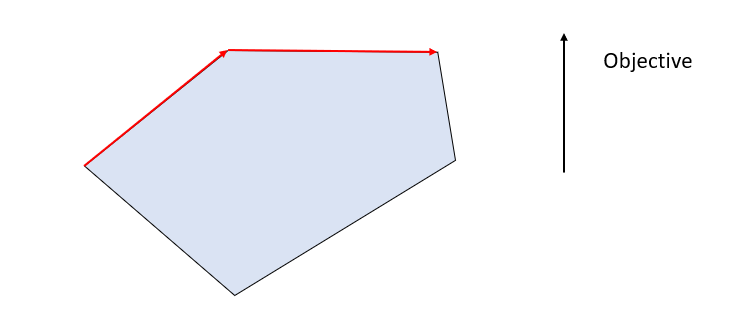

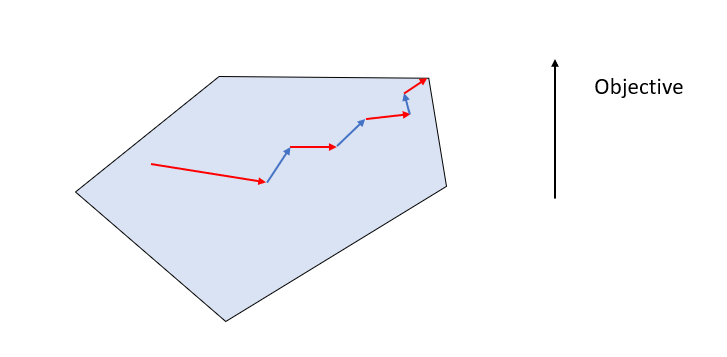

In [ ]:
m = new_ampl()
m.eval(r"""
var x integer >= 0;
var y >= 0;
maximize Total_Cost: 3*x+4*y;
subject to c1: 2*x+y <= 10;
subject to c2: x+3*y <= 12;
""")

solve_checked(m)
print("x =", m.var["x"].value())
print("y =", m.var["y"].value())
print("Optimal value:", m.obj["Total_Cost"].value())


## B-and-B and B-and-C
* Presolve
* Node selection
* Node presolve
* Linear relaxation
* Cutting planes
* Heuristics
* Branching

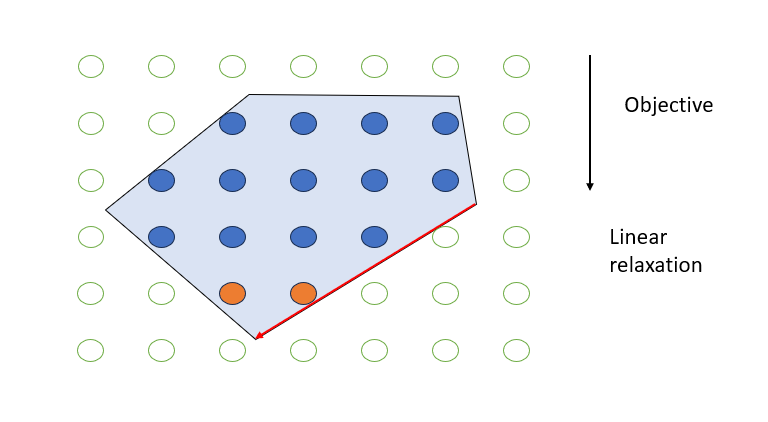

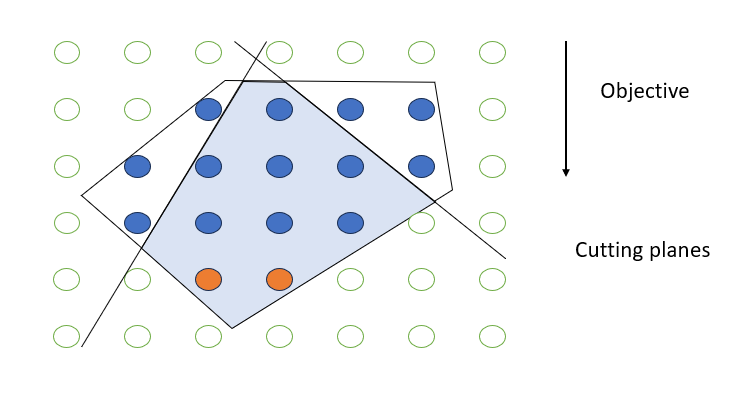

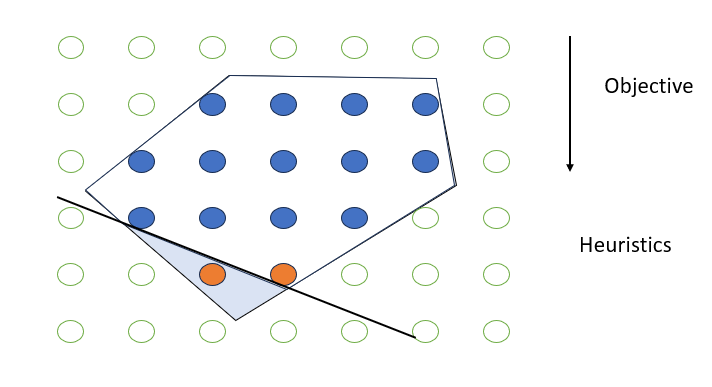

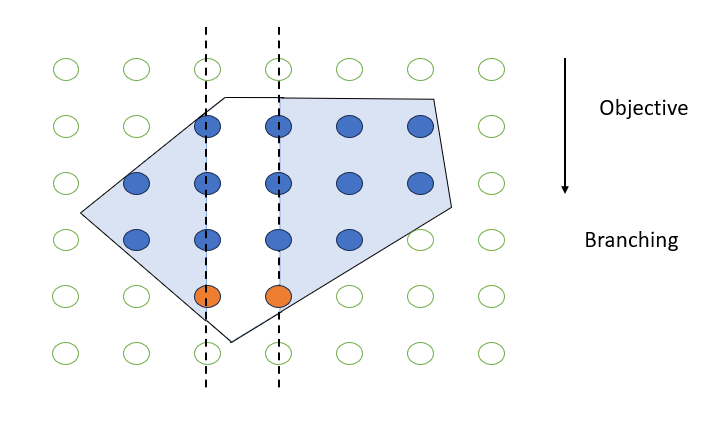

# How simplex works in LP

In [ ]:
!pip install gilp

In [ ]:
from gilp.visualize import simplex_visual
from gilp.simplex import LP
import numpy as np

In [ ]:
A = np.array([[0, 1, -1],
              [1, -1, 1],
              [1, 0, 1],
              [2, -1, 0]])
b = np.array([[4],
              [2],
              [3],
              [0]])
c = np.array([[1],
              [2],
              [3]])
# Alternatively
#b = np.array([4,2,3,0])
#c = np.array([1,2])

lp = LP(A,b,c)

In [ ]:
simplex_visual(lp).show()

In [ ]:
A1 = np.array([[2, 1,],
              [1, 3]])
b1 = np.array([[10],
              [12]])
c1 = np.array([[3],
              [4]])

lp1 = LP(A1,b1,c1)
simplex_visual(lp1).show()